---   
 <img align="left" width="75" height="75"  src="https://upload.wikimedia.org/wikipedia/en/c/c8/University_of_the_Punjab_logo.png"> 

<h1 align="center">Department of Data Science</h1>

---
<h3><div align="right">Instructor: Muhammad Arif Butt, Ph.D.</div></h3>    

<br><br>
<h1 align="center">Lec-13: Multi-Modality of AI Models (Part-I)</h1>

# Learning agenda of this notebook

1. Image → Text (Visual Understanding)
2. Image → Text (Image Classification)
3. Text → Image (Image Generation)
4. Image → Image (Image Segmentation)

# Overview of Multi-Modality
<h2 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">Models that are able to deal with different types (or modalities) of data, such as text, code, images, audio, video, or sensors, are said to be multimodal. It’ s possible for a model to accept a modality as input yet not be able to generate in that modality.</div></h2>

<div style="text-align: center;">
    <img src="../images/multimodal1.png" width="1500">
</div>

# Application-based Taxonomy of Transformer Models
<div style="text-align: center;">
    <img src="../images/multimodality-taxonomy.png" width="2000">
</div>


<img align=right src="../images/multimodal2.png" width="1000">

# 1. <span style='background :lightgreen' >Image → Text (Visual Understanding)</span>
- Image-to-text translation, also known as **visual understanding**, is the process where AI models analyze an image and describe its contents in natural language. These systems can generate captions, extract structured details, or reason about the scene — making images searchable, accessible, and easier to interpret.
- Both the original Transformer as well as the Vision Transformer take unstructured data, convert it to numerical representations, and finally use that for tasks like classification.
- **Closed Source:**
    - **GPT-4o:** OpenAI’s multimodal “omni” model that can process text, images, and audio, enabling detailed image descriptions and contextual reasoning. (https://openai.com/index/introducing-4o/)
    - **GPT-4 Vision:** A variant of GPT-4 with vision capabilities, able to interpret images, extract structured information, and support accessibility use cases. (https://openai.com/research/gpt-4)
    - **Claude 3.5 Opus:** Anthropic’s most capable multimodal model, designed for high reasoning depth, detailed analysis, and complex visual interpretation. (https://www.anthropic.com/news/claude-3-5)
    - **Claude 3.5 Sonnet:** Balanced multimodal model by Anthropic offering strong vision understanding with faster performance than Opus. (https://www.anthropic.com/news/claude-3-5)
    - **Gemini Vision Pro:** Google DeepMind’s flagship multimodal model (Gemini 1.5 Pro) that can analyze images, charts, and videos with high accuracy and contextual awareness. (https://deepmind.google/technologies/gemini/#introduction)
- **Open Source:**
    - **LLaVA:** Large Language and Vision Assistant (based on LLaMA + CLIP), enabling conversational image understanding with strong open-weight benchmarks. (https://llava-vl.github.io/)
    - **BLIP-2:** Bootstrapping Language-Image Pre-training framework that bridges pre-trained vision encoders with LLMs for zero-shot image captioning and reasoning. (https://huggingface.co/docs/transformers/model_doc/blip-2)
    - **Qwen-VL:** Alibaba’s open-source multimodal model family with strong image captioning, OCR, and visual question answering capabilities. (https://huggingface.co/Qwen)
    - **CogVLM:** A visual language model optimized for reasoning-rich image understanding tasks, integrating strong vision encoders with large language models. (https://huggingface.co/THUDM/CogVLM)
- **Example Prompts:**
    - Upload a messy desk → “Describe this scene and suggest organization tips.”
    - Upload a chart → “Explain what this graph is showing and identify key trends.”
    - Upload a historical photo → “Analyze the time period and context of this image.”

>- DALL·E models (DALL·E 2 and DALL·E 3) cannot “describe” images in the same way GPT-4o-mini can. They are generative models, meant for creating or editing images from text prompts, not for analyzing or producing textual descriptions of an existing image.

In [2]:
#  Load the API  API Keys
import os
from dotenv import load_dotenv
load_dotenv('../keys/.env', override=True) 

openai_api_key = os.getenv('OPENAI_API_KEY')
anthropic_api_key = os.getenv('ANTHROPIC_API_KEY')
google_api_key = os.getenv('GOOGLE_API_KEY')
groq_api_key = os.getenv("GROQ_API_KEY")
hf_token = os.getenv('HF_TOKEN')

if openai_api_key:
    print(f"OpenAI API Key exists and begins {openai_api_key[:8]}")
else:
    print("OpenAI API Key not set")
    
if anthropic_api_key:
    print(f"Anthropic API Key exists and begins {anthropic_api_key[:8]}")
else:
    print("Anthropic API Key not set")

if google_api_key:
    print(f"Google API Key exists and begins {google_api_key[:8]}")
else:
    print("Google API Key not set (and this is optional)")

if groq_api_key:
    print(f"Groq API Key exists and begins {groq_api_key[:8]}")
else:
    print("Groq API Key not set")

if hf_token:
    print(f"Hugging Face Tokens exists and begins {hf_token[:8]}")
else:
    print("Hugging Face tokens not set")


OpenAI API Key exists and begins sk-proj-
Anthropic API Key exists and begins sk-ant-a
Google API Key exists and begins AIzaSyDA
Groq API Key exists and begins gsk_LyFp
Hugging Face Tokens exists and begins hf_oEyHP


## a. Example 1

In [2]:
from IPython.display import Image, display
display(Image(url='https://www.arifbutt.me/wp-content/uploads/2025/09/arif-img.jpeg', width=600)) # For URLs - you MUST use the url parameter otherwise just pass the path of local file

### Using `gpt-4o-mini` (Passing the image URL)
- OpenAI’s GPT-4o-mini is a multimodal model capable of understanding and describing images through the OpenAI Chat API.
- To the `client.responses.create()` method, the user role takes the input_text (text instructions) and input_image (via URL or base64 format) and returns a detailed description or analysis of the image as per the text instructions.
- To the OpenAI models like GPT-4o, GPT-4o-mini, and DALL·E 3 you can pass images in two ways:
    - URL reference ({"type": "image_url", "url": "https://example.com/img.jpg"})
    - Base64 encoding (if the image is local and not hosted anywhere).
- if you are using an image URL you don’t need to encode the image to base64 for OpenAI models.

In [3]:
from openai import OpenAI

client = OpenAI(api_key=openai_api_key)

response = client.responses.create(
                    model="gpt-4o-mini",  # Vision-capable model
                    input=[
                            {"role": "system", "content": "You are a helpful assistant."},
                            {"role": "user","content": [     # Instead of string, here content is a list of dictionaries
                                                        {"type": "input_text", "text": "Describe this image:"},                            # Text prompt
                                                        {"type": "input_image", "image_url": "https://www.arifbutt.me/wp-content/uploads/2025/09/arif-img.jpeg"} # Provide an image URL or base64 data here   
                                                      ]
                            }
                        ],
                    max_output_tokens=512,
                    temperature=0.7
)
print(response.output_text)

The image appears to be a promotional graphic for a lecture on data science. It includes the following elements:

- The title "TOOLS & TECHNIQUES DATA SCIENCE" prominently displayed.
- A lecture number "2.1" indicated.
- An image of a man in professional attire, possibly the lecturer.
- The name "Dr. Muhammad Arif Butt" is mentioned.
- Various logos or icons related to data science tools and techniques are arranged around the text, likely representing software or programming languages commonly used in the field.

The overall design is likely intended to be informative and visually engaging for viewers interested in data science.


### Using `gpt-4o-mini` (Passing a local image in base64 format)

In [9]:
import base64       # for encoding the image into Base64
from openai import OpenAI

# --------------------------------------------------------------------------------
# Load your image as base64 as Anthropic models expect images encoded using base64
# --------------------------------------------------------------------------------
#f = open("../images/imagetotext1.jpg", "rb")    # Open the image file in binary mode
f = open("../images/arif-img.jpeg", "rb")    # Open the image file in binary mode
image_bytes = f.read()                       # Read the file contents (binary data)
base64_bytes = base64.b64encode(image_bytes) # Encodes the binary image data into Base64 format (a text-friendly encoding)
base64_image = base64_bytes.decode("utf-8")  # Converts the Base64 bytes into a regular UTF-8 string (so it can be inserted into JSON or passed in an API request).
f.close()                                    # Close the file
# base64_image now holds a long Base64-encoded string version of your image like "iVBORw0KGgoAAAANSUhEUgAA..."


client = OpenAI(api_key=openai_api_key)

response = client.responses.create(
                    model="gpt-4o-mini",  # Vision-capable model
                    input=[
                            {"role": "system", "content": [{"type": "input_text", "text": "You are a helpful assistant."}]},
                            {"role": "user","content": [
                                                        {"type": "input_text", "text": "Describe this image:"},                           # Text prompt
                                                        {"type": "input_image", "image_url": f"data:image/jpeg;base64,{base64_image}"}    # Provide an image URL or base64 data here   
                                                      ]
                            }
                        ],
                    max_output_tokens=512,
                    temperature=0.7
                )
print(response.output_text)

The image appears to be a promotional graphic for a lecture on data science tools and techniques. It features a man, presumably Dr. Muhammad Arif Butt, standing confidently with his arms crossed. The background includes various logos of data science tools and programming languages, suggesting a focus on practical applications in the field. The lecture is labeled as "Lecture # 2.1," indicating it is part of a series. The overall design is professional and academic in nature.


### Using `meta-llama/llama-4-scout-17b-16e-instruct` with OpenAI Responses API (Groq Router)
- The `meta-llama/llama-4-scout-17b-16e-instruct` is Groq’s native multimodal model with built-in vision support — capable of processing image inputs alongside text.
- The Responses API is compatible with image fields, so this form will trigger a vision + language response rather than a text-only answer.

In [11]:
import os
from dotenv import load_dotenv
from openai import OpenAI
from IPython.display import Markdown, display

# Initialize OpenAI client pointed at Groq
client = OpenAI(base_url="https://api.groq.com/openai/v1", api_key=groq_api_key)

response = client.responses.create(
                                    model="meta-llama/llama-4-scout-17b-16e-instruct",  # Vision-capable model
                                    input=[
                                            {"role": "system", "content": [{"type": "input_text", "text": "You are a helpful assistant."}]},
                                            {"role": "user","content": [
                                                                        {"type": "input_text", "text": "Describe this image:"},                            # Text prompt
                                                                        {"type": "input_image", "image_url": "https://www.arifbutt.me/wp-content/uploads/2025/09/arif-img.jpeg"} # Provide an image URL or base64 data here   
                                                                      ]
                                            }
                                        ],
                                    max_output_tokens=512,
                                    temperature=0.7
                                )
display(Markdown(response.output_text))

The image appears to be a slide from a presentation on data science, specifically lecture number 2.1 titled "TOOLS & TECHNIQUES DATA SCIENCE." 

The slide features a man in a gray suit with his arms crossed, likely the presenter or instructor, Dr. Muhammed Arif Butt. The background of the slide is beige, with a blue section on the right side featuring various logos. 

Overall, the image suggests that it is part of an educational presentation or course on data science, possibly taught by Dr. Muhammed Arif Butt.

### Using `claude-3-5-haiku`
- To the Anthropic models like Claude 3.5 Sonnet/Haiku/Opus with vision, images must be provided in base64 encoding inside the API request (no direct URL input like OpenAI as of now).

In [5]:
import base64       # for encoding the image into Base64
import anthropic    # for calling Anthropic's Claude models

# --------------------------------------------------------------------------------
# Load your image as base64 as Anthropic models expect images encoded using base64
# --------------------------------------------------------------------------------
with open("../images/arif-img.jpeg", "rb") as f:
    base64_image = base64.b64encode(f.read()).decode("utf-8")

client = anthropic.Anthropic(api_key=anthropic_api_key)
response = client.messages.create(
                                    model="claude-3-5-haiku-20241022",   # or "claude-3-5-sonnet-20240620" or "claude-3-5-opus-20240620"
                                    max_tokens=500,
                                    messages=[{"role": "user","content": [{"type": "text", "text": "Describe this image."}, {"type": "image","source": {"type": "base64", "media_type": "image/jpeg","data": base64_image,
                                                },},],}],
                                )

print(response.content[0].text)
# media_type can be "image/png" , "image/gif" or "image/webp" if needed

This image appears to be a lecture slide or presentation banner for a Data Science course. The slide is titled "Tools & Techniques" with "Lecture 2.1" prominently displayed. A person wearing a gray suit is standing with crossed arms, positioned on the left side of the image. On the right side, there are various logos of tech companies and tools related to data science. The name "Dr. Muhammad Arif Butt" is also shown, suggesting he is the lecturer for this session.


### Using `vit-gpt2-image-captioning`
- For image-to-text models (a.k.a. image captioning), you don’t strictly need a GPU, but using one (e.g. Google Colab GPU runtime) speeds up inference significantly.
- A standard image captioning model on Hugging Face is available at: https://huggingface.co/nlpconnect/vit-gpt2-image-captioning
- The `vit-gpt2-image-captioning` model combines:
    - **ViT (Vision Transformer)** → encodes the input image into a latent representation.
    - **GPT-2 decoder** → generates natural language captions from the visual features.
- When you load this model for the first time, the following files are downloaded into your Hugging Face cache (~/.cache/huggingface/ by default):
    - `pytorch_model.bin` (ViT encoder + GPT-2 decoder weights) → ~500 MB
    - `preprocessor_config.json`, `tokenizer.json`, `vocab.json`, `merges.txt` → a few MB
    - `config.json` and supporting files
- Total size ≈ 500–600 MB, much lighter than diffusion models used for image generation.

In [4]:
import base64
from transformers import pipeline

# --------------------------------------------------------------------------------
# Load your image as base64 as Anthropic models expect images encoded using base64
# --------------------------------------------------------------------------------
with open("../images/arif-img.jpeg", "rb") as f:
    base64_image = base64.b64encode(f.read()).decode("utf-8")


# Load the image-to-text pipeline from the transformers library
pipe = pipeline("image-to-text",  model = "nlpconnect/vit-gpt2-image-captioning",  device = -1)

response = pipe(base64_image, max_new_tokens=512)

# It returns a list of dictionaries (because pipelines are batch-capable). Since we passed a single image, the pipeline returns a list with just one element and [0] extracts the first dictionary.
print(response[0]['generated_text']) # From that dictionary, we access the key "generated_text", which holds the actual caption string.

/Users/arif/Documents/genai-course/.venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cpu
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooti

a man in a suit and tie is talking on a cell phone 


## b. Example 2

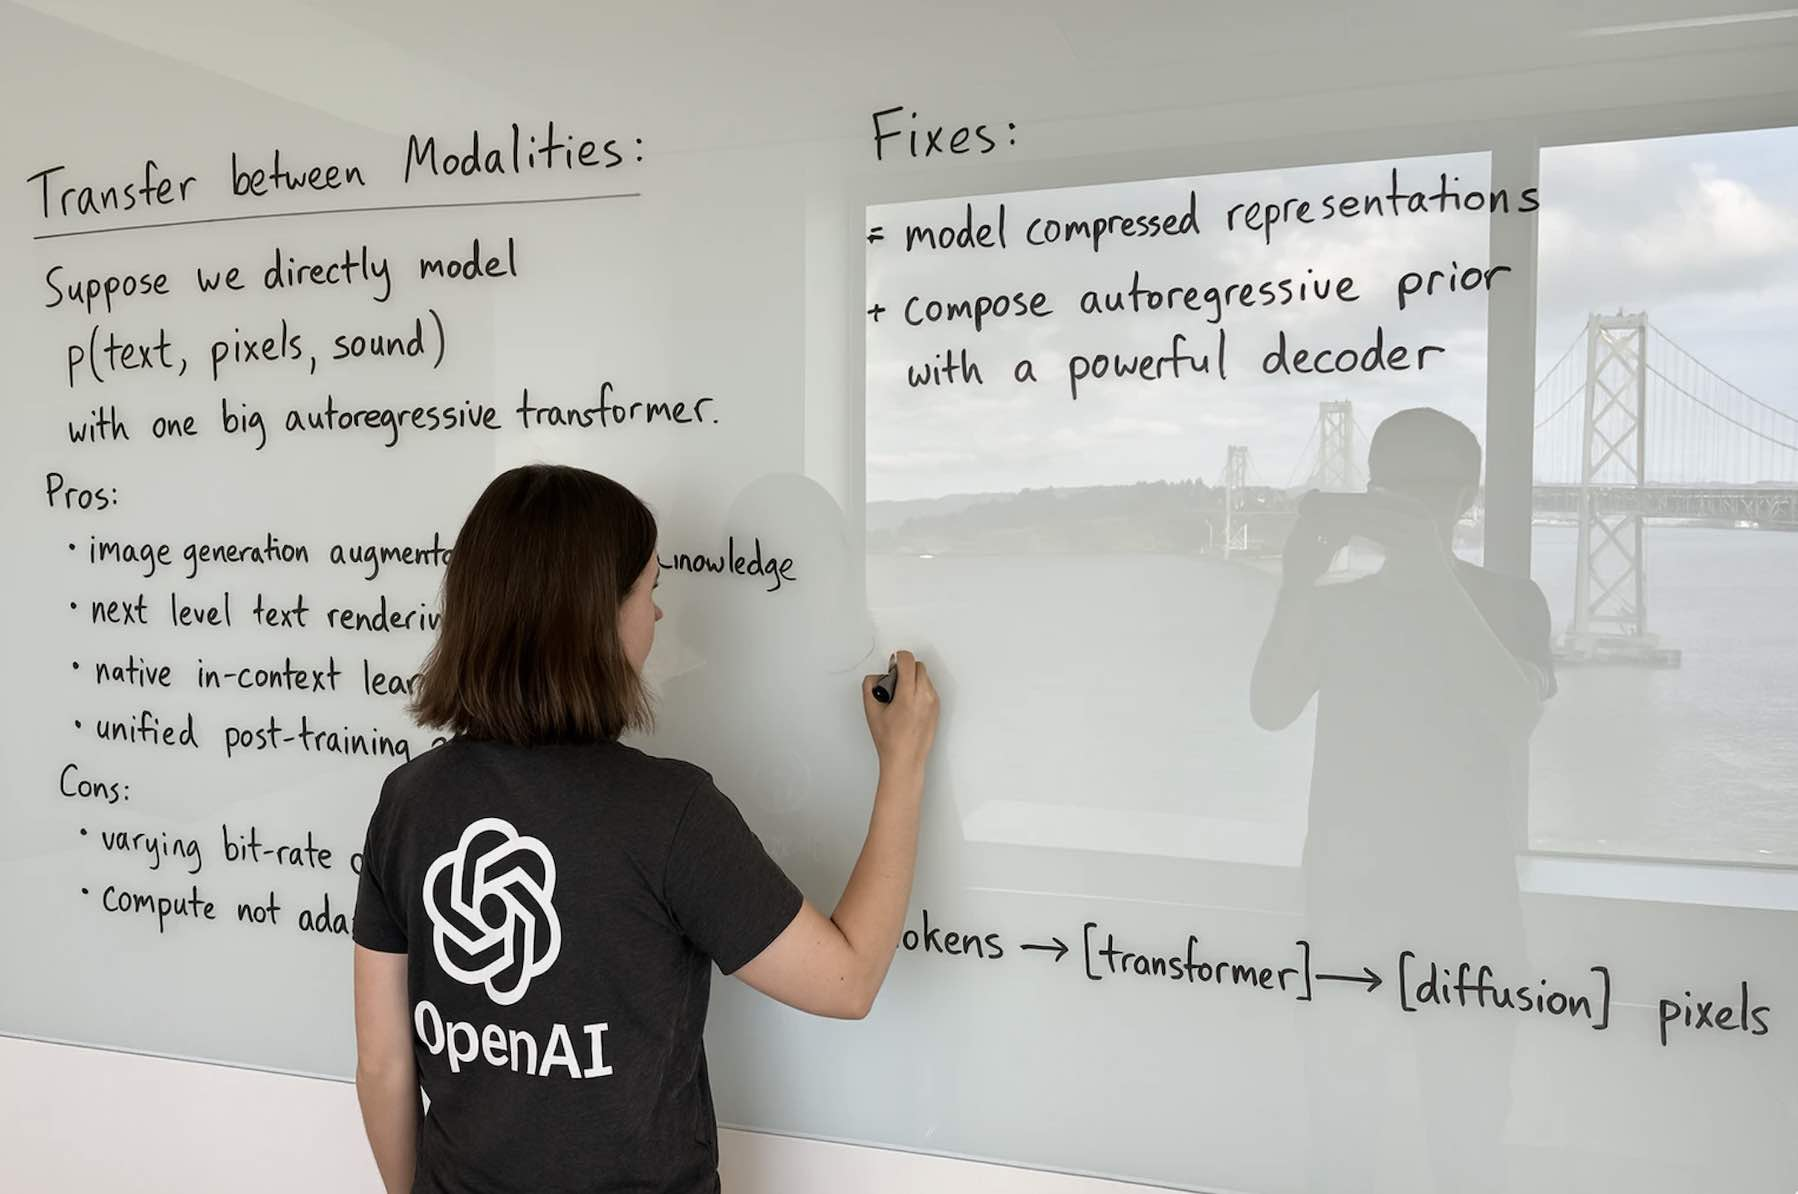

In [5]:
from IPython.display import Image, display
display(Image('../images/imagetotext1.jpg', width=600))

### Using `gpt-4o-mini`

In [27]:
import base64       # to encode the image into Base64
from openai import OpenAI   # to call GPT-4o-mini through the OpenAI client

# -------------------------
# Load your image as base64
# -------------------------
with open("../images/imagetotext1.jpg", "rb") as f:
    base64_image = base64.b64encode(f.read()).decode("utf-8")

messages = [
            {"role": "system", "content": [{"type": "input_text", "text": "You are a helpful assistant."}]},
            {"role": "user", "content": [
                                            {"type": "input_text", "text": "Describe this image."},
                                            {"type": "input_image", "image_url": f"data:image/jpeg;base64,{base64_image}"}
                                        ]
            }
           ]

client = OpenAI(api_key=openai_api_key)
response = client.responses.create(
    model="gpt-4o-mini",
    input=messages
)
print(response.output_text)

The image shows a person standing in front of a whiteboard with handwritten notes. The notes discuss the concept of "Transfer between Modalities" in machine learning, specifically modeling relationships between text, pixels, and sound using an autoregressive transformer.

On the whiteboard, there's a list of pros and cons associated with this approach. The pros include points such as "image generation augmentation" and "next level text rendering." The cons mention issues like "varying bit-rate options" and "compute not adaptable."

Additionally, there are proposed "fixes" listed, which suggest modeling compressed representations and enhancing the autoregressive prior with a better decoder. A diagram is also visible, illustrating a flow from tokens to transformer and diffusion processes.

In the background, a bridge can be seen through a window, indicating a scenic view outside. The person writing is wearing a t-shirt with the OpenAI logo on it.


### Using `meta-llama/llama-4-scout-17b-16e-instruct` with OpenAI Responses API (Groq Router)

In [6]:
from openai import OpenAI
from IPython.display import Markdown, display

# -------------------------
# Load your image as base64
# -------------------------
with open("../images/imagetotext1.jpg", "rb") as f:
    base64_image = base64.b64encode(f.read()).decode("utf-8")


# Initialize OpenAI client pointed at Groq
client = OpenAI(base_url="https://api.groq.com/openai/v1", api_key=groq_api_key)

response = client.responses.create(
                                    model="meta-llama/llama-4-scout-17b-16e-instruct",  # Vision-capable model
                                    input=[
                                            {"role": "system", "content": [{"type": "input_text", "text": "You are a helpful assistant."}]},
                                            {"role": "user","content": [
                                                                        {"type": "input_text", "text": "Describe this image:"},                            # Text prompt
                                                                        {"type": "input_image", "image_url": f"data:image/jpeg;base64,{base64_image}"}
                                                                      ]
                                            }
                                        ],
                                    max_output_tokens=512,
                                    temperature=0.7
                                )
display(Markdown(response.output_text))

The image depicts a woman writing on a whiteboard with a marker. The whiteboard is divided into two sections, each containing handwritten text.

**Left Section:**

* Title: "Transfer between Modalities:"
* Text: "Suppose we directly model p(text, pixels, sound) with one big autoregressive transformer."
* Pros:
	+ Image generation augmenta
	+ Next level text renderiv
	+ Native in-context learn
	+ Unified post-training
* Cons:
	+ Varying bit-rate
	+ Compute not ada

**Right Section:**

* Title: "Fixes:"
* Text: "= model compressed representations + compose autoregressive prior with a powerful decoder"

The woman has brown hair and wears a black t-shirt with the OpenAI logo. She faces away from the camera, holding a black marker in her right hand as she writes on the board. A reflection of a man taking a photo of himself can be seen on the right side of the board.

In the background, a bridge over water is visible through a window behind the whiteboard. The overall atmosphere suggests that the woman is presenting information related to artificial intelligence or machine learning, possibly in an educational or professional setting.

### Using `claude-3-5-haiku`

In [14]:
import base64       # for encoding the image into Base64
import anthropic    # for calling Anthropic's Claude models


# -------------------------
# Load your image as base64
# -------------------------
with open("../images/imagetotext1.jpg", "rb") as f:
    base64_image = base64.b64encode(f.read()).decode("utf-8")

client = anthropic.Anthropic(api_key=anthropic_api_key)
response = client.messages.create(
                                    model="claude-3-5-haiku-20241022",   # or "claude-3-5-sonnet-20240620" or "claude-3-5-opus-20240620"
                                    max_tokens=500,
                                    messages=[{"role": "user","content": [{"type": "text", "text": "Describe this image."}, {"type": "image","source": {"type": "base64", "media_type": "image/jpeg","data": base64_image,
                                                },},],}],
                                )

print(response.content[0].text)
# media_type can be "image/png" , "image/gif" or "image/webp" if needed

The image shows a technical whiteboard presentation about transfer between modalities and fixes in machine learning. A person wearing an OpenAI t-shirt is writing on a whiteboard, with notes about modeling different types of data (text, pixels, sound) using transformers. The left side of the board lists "Pros" and "Cons" of this approach, while the right side discusses fixes like model compressed representations and composing autoregressive priors. In the background, there's a window with a view of a bridge, creating a reflective backdrop to the technical discussion.


### Using `vit-gpt2-image-captioning`

In [15]:
import base64
from transformers import pipeline

# --------------------------------------------------------------------------------
# Load your image as base64 as Anthropic models expect images encoded using base64
# --------------------------------------------------------------------------------
with open("../images/imagetotext1.jpg", "rb") as f:
    base64_image = base64.b64encode(f.read()).decode("utf-8")


# Load the image-to-text pipeline from the transformers library
pipe = pipeline("image-to-text",  model = "nlpconnect/vit-gpt2-image-captioning",  device = -1)

response = pipe(base64_image, max_new_tokens=100)

# It returns a list of dictionaries (because pipelines are batch-capable). Since we passed a single image, the pipeline returns a list with just one element and [0] extracts the first dictionary.
print(response)
print(response[0]['generated_text']) # From that dictionary, we access the key "generated_text", which holds the actual caption string.

Device set to use cpu


[{'generated_text': 'a woman is standing in front of a wall with a sign '}]
a woman is standing in front of a wall with a sign 


## c. Example 3

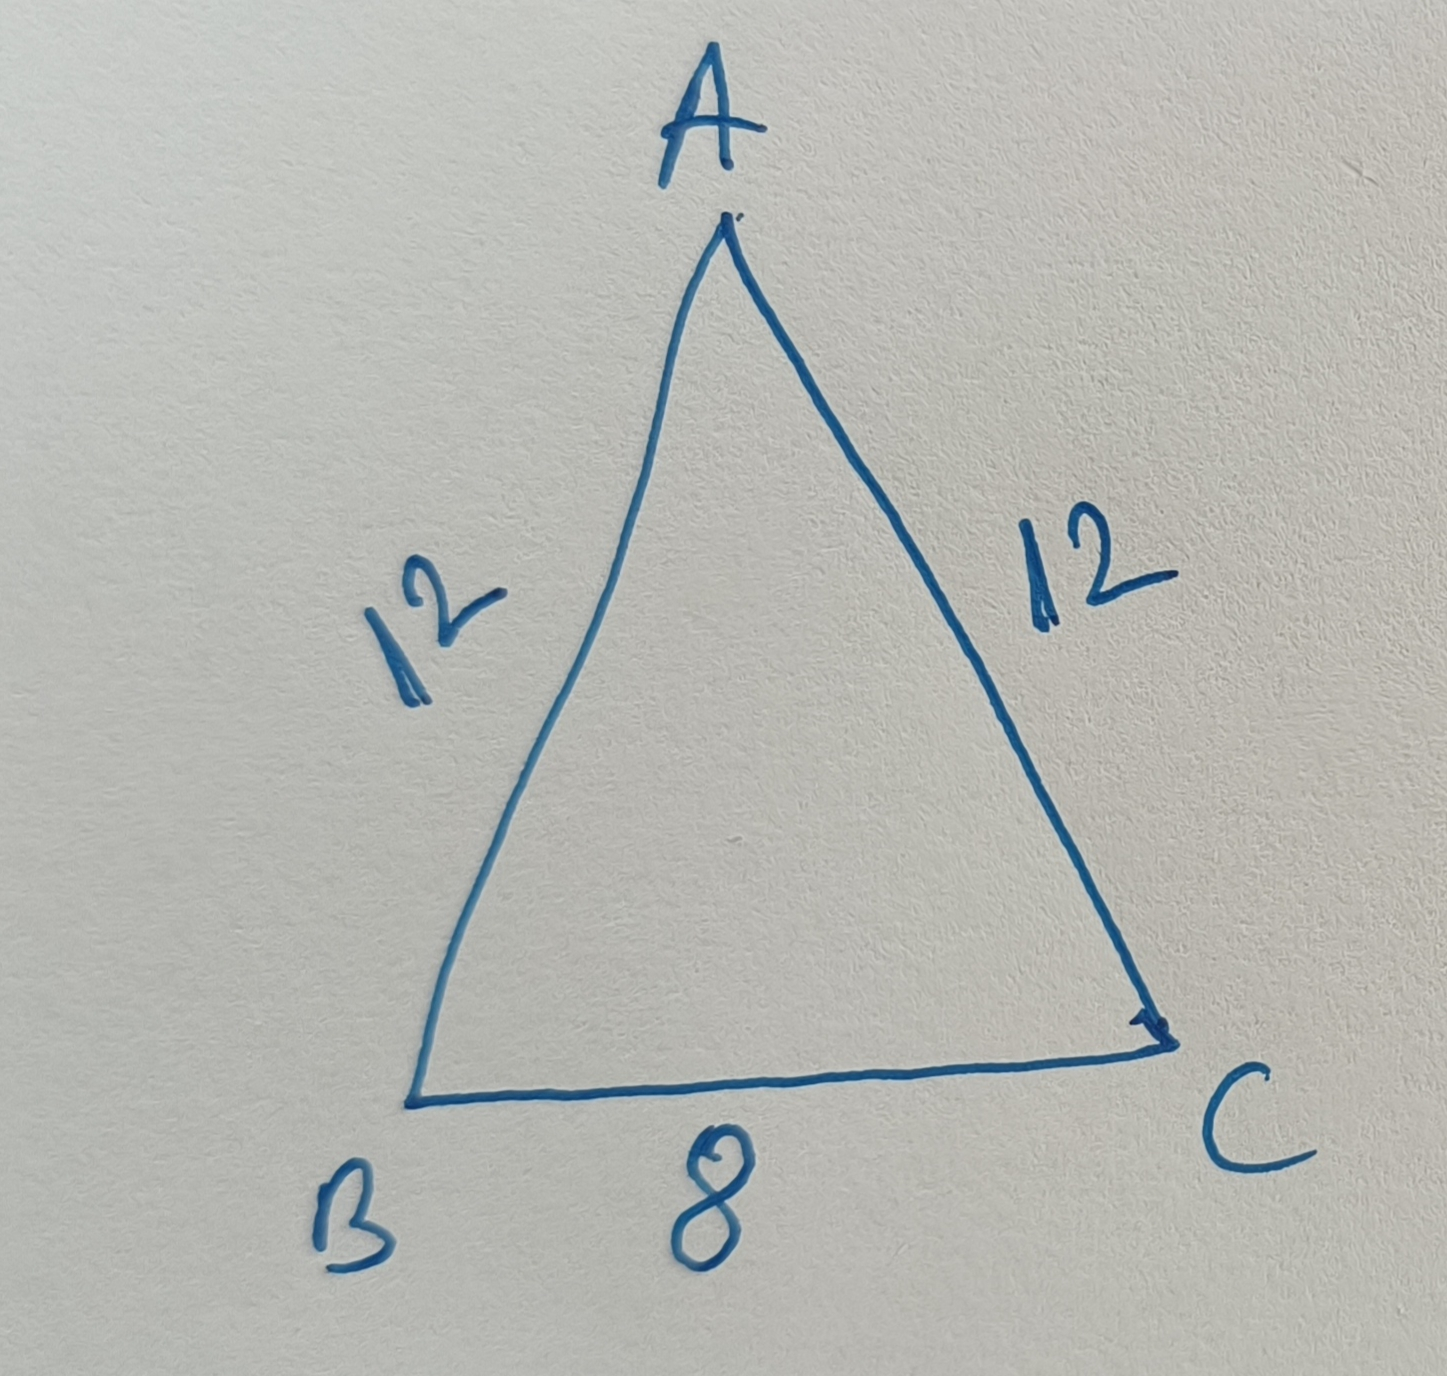

In [6]:
from IPython.display import Image, display
display(Image('../images/triangle1.jpg', width=400))

### Using `gpt-4o-mini`

In [8]:
import base64       # to encode the image into Base64
from openai import OpenAI   # to call GPT-4o-mini through the OpenAI client

# -------------------------
# Load your image as base64
# -------------------------
with open("../images/triangle1.jpg", "rb") as f:
    base64_image = base64.b64encode(f.read()).decode("utf-8")

messages = [
            {"role": "system", "content": [{"type": "input_text", "text": "You are a helpful assistant."}]},
            {"role": "user", "content": [
                                            {"type": "input_text", "text": "Yor are an expert math teacher. Tell me the perimeter of the triangle shown in this image.."},
                                            {"type": "input_image", "image_url": f"data:image/jpeg;base64,{base64_image}"}
                                        ]
            }
           ]

client = OpenAI(api_key=openai_api_key)
response = client.responses.create(
    model="gpt-4o-mini",
    input=messages
)
print(response.output_text)

To find the perimeter of the triangle \( ABC \), you need to sum the lengths of all its sides.

The sides of the triangle are:

- \( AB = 12 \)
- \( AC = 12 \)
- \( BC = 8 \)

Now, add these lengths together:

\[
\text{Perimeter} = AB + AC + BC = 12 + 12 + 8
\]

\[
\text{Perimeter} = 32
\]

Thus, the perimeter of the triangle is \( 32 \) units.


### Using `claude-3-5-haiku`

In [19]:
import base64       # for encoding the image into Base64
import anthropic    # for calling Anthropic's Claude models


# -------------------------
# Load your image as base64
# -------------------------
with open("../images/triangle1.jpg", "rb") as f:
    base64_image = base64.b64encode(f.read()).decode("utf-8")

client = anthropic.Anthropic(api_key=anthropic_api_key)
response = client.messages.create(
                                    model="claude-3-5-haiku-20241022",   # or "claude-3-5-sonnet-20240620" or "claude-3-5-opus-20240620"
                                    max_tokens=500,
                                    messages=[{"role": "user","content": [{"type": "text", "text": "Yor are an expert math teacher. Tell me the perimeter of the triangle shown in this image."}, 
                                                                          {"type": "image","source": {"type": "base64", "media_type": "image/jpeg","data": base64_image,
                                                }}]}]
                                )

print(response.content[0].text)
# media_type can be "image/png" , "image/gif" or "image/webp" if needed

To calculate the perimeter of the triangle, I'll add up the lengths of all three sides:

Side BC (bottom) = 8
Side AB (left side) = 12
Side AC (right side) = 12

Perimeter = 8 + 12 + 12 = 32

The perimeter of the triangle is 32 units.


### Using `vit-gpt2-image-captioning`

In [9]:
import base64
from transformers import pipeline

# --------------------------------------------------------------------------------
# Load your image as base64 as Anthropic models expect images encoded using base64
# --------------------------------------------------------------------------------
with open("../images/triangle1.jpg", "rb") as f:
    base64_image = base64.b64encode(f.read()).decode("utf-8")


# Load the image-to-text pipeline from the transformers library
pipe = pipeline("image-to-text",  model = "nlpconnect/vit-gpt2-image-captioning",  device = -1)

response = pipe(base64_image, max_new_tokens=100)

# It returns a list of dictionaries (because pipelines are batch-capable). Since we passed a single image, the pipeline returns a list with just one element and [0] extracts the first dictionary.
print(response)
print(response[0]['generated_text']) # From that dictionary, we access the key "generated_text", which holds the actual caption string.

Device set to use cpu


[{'generated_text': 'a drawing of a bird on a blue and white board '}]
a drawing of a bird on a blue and white board 


## d. Example 4

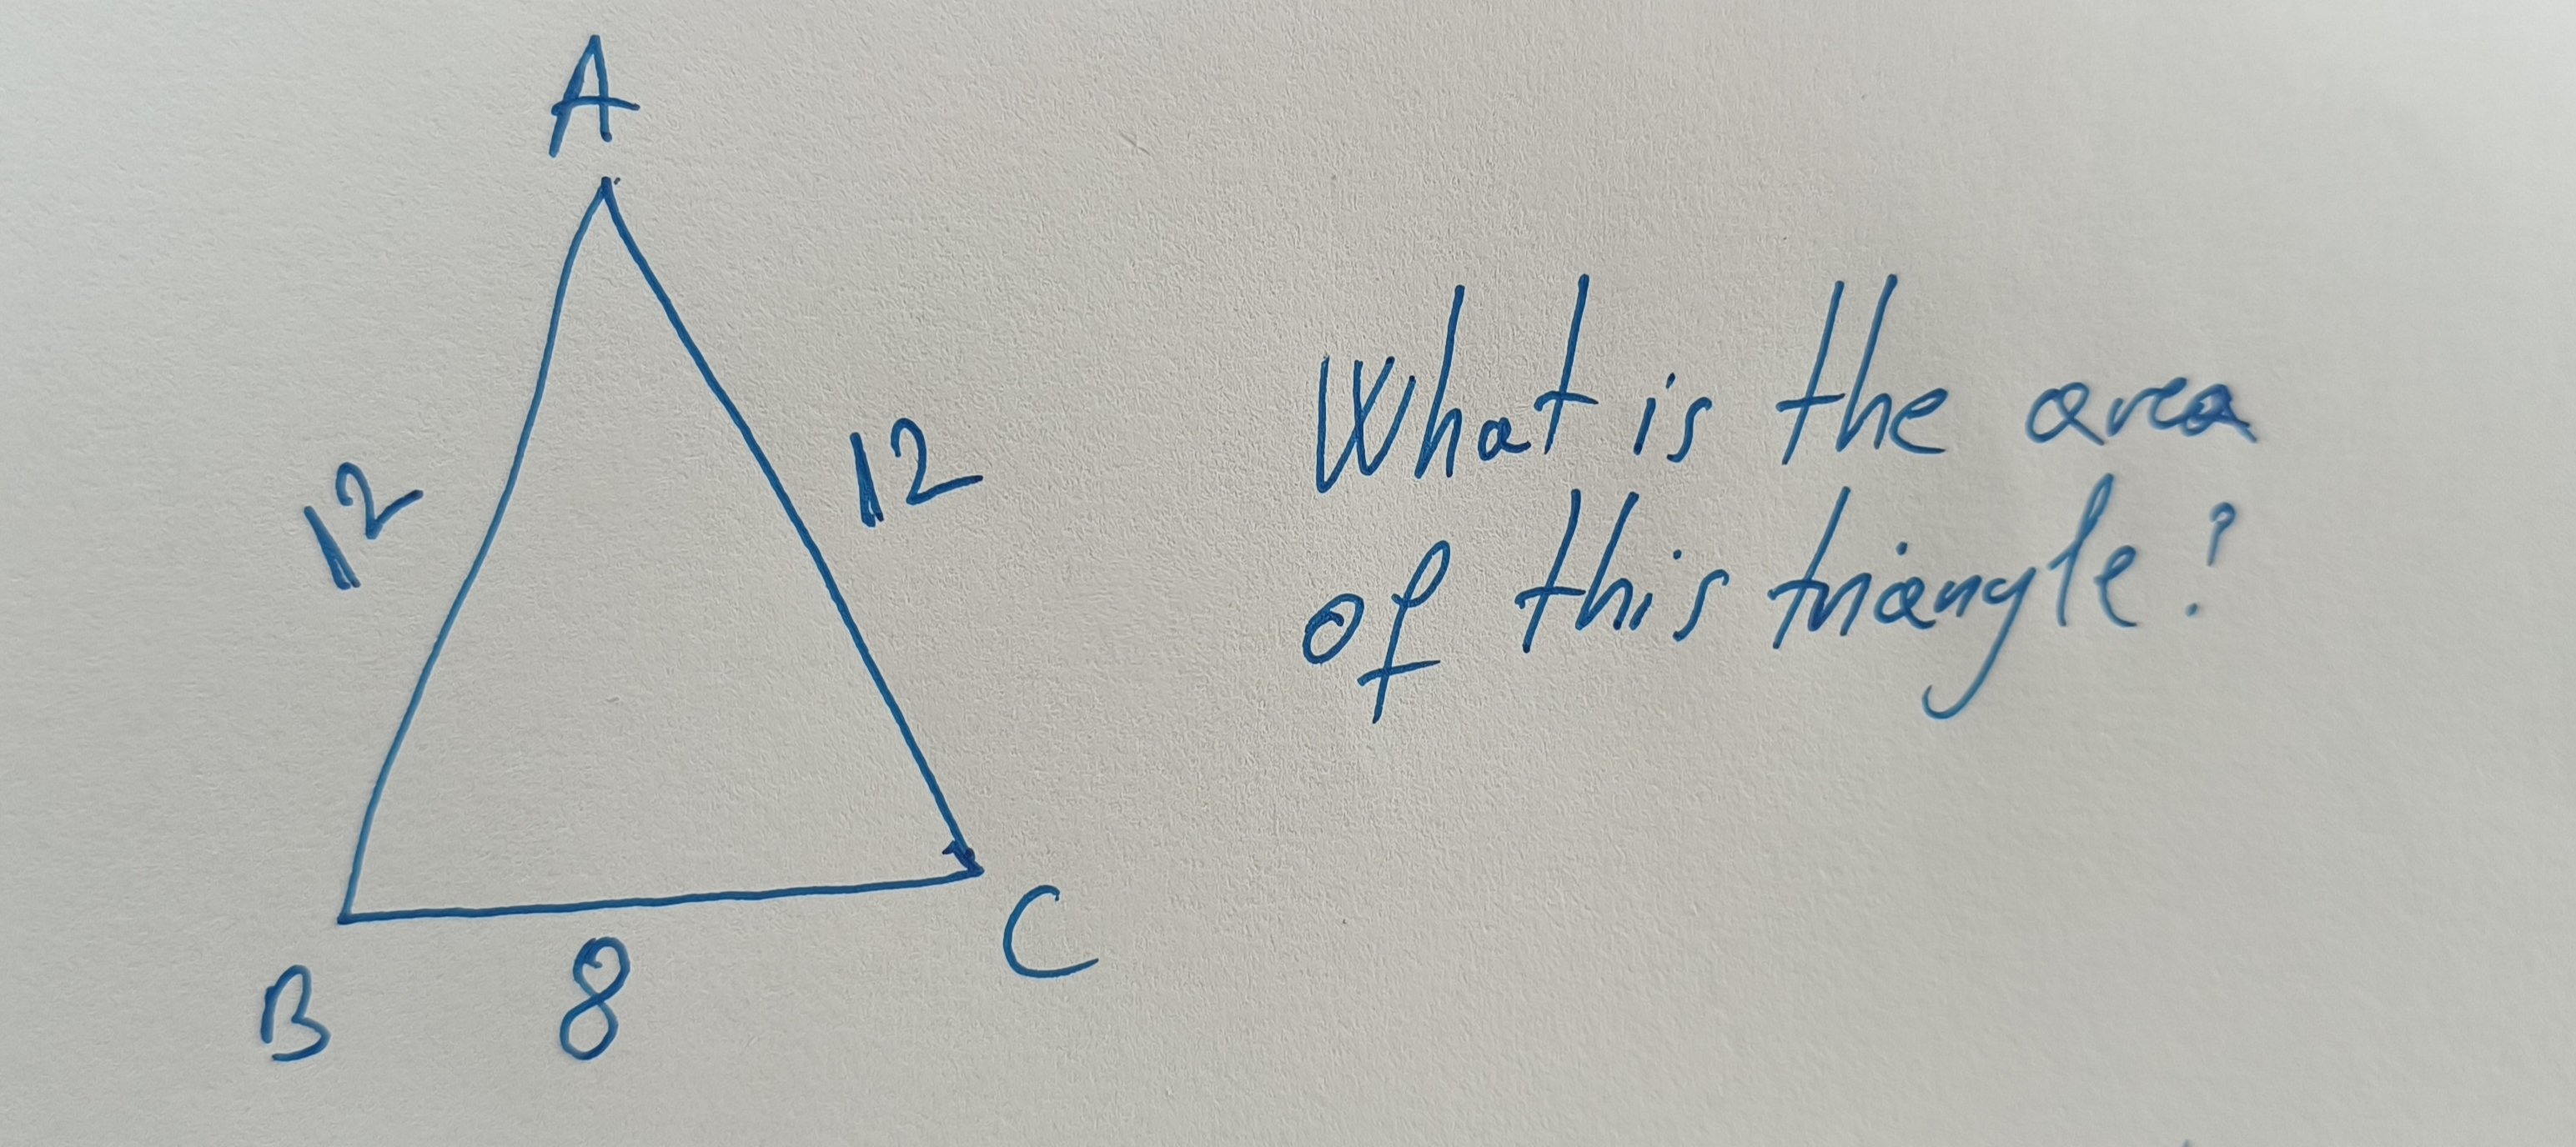

In [22]:
from IPython.display import Image, display
display(Image('../images/triangle2.jpg', width=600))

### Using `claude-3-5-haiku`

In [23]:
import base64       # for encoding the image into Base64
import anthropic    # for calling Anthropic's Claude models


# -------------------------
# Load your image as base64
# -------------------------
with open("../images/triangle2.jpg", "rb") as f:
    base64_image = base64.b64encode(f.read()).decode("utf-8")

client = anthropic.Anthropic(api_key=anthropic_api_key)
response = client.messages.create(
                                    model="claude-3-5-haiku-20241022",   # or "claude-3-5-sonnet-20240620" or "claude-3-5-opus-20240620"
                                    max_tokens=500,
                                    messages=[{"role": "user","content": [{"type": "text", "text": "Yor are an expert math teacher. Solve the problem given in the image using Pythagorean theorem"}, 
                                                                          {"type": "image","source": {"type": "base64", "media_type": "image/jpeg","data": base64_image,
                                                }}]}]
                                )

print(response.content[0].text)
# media_type can be "image/png" , "image/gif" or "image/webp" if needed

Let's solve this step by step:

1) First, let's verify if this is a right triangle using the Pythagorean theorem:
   Side BC = 8
   Side AC = 12
   Side AB = unknown height

2) Let's find the height (AB) using Pythagorean theorem:
   AB² = 12² - 8²
   AB² = 144 - 64
   AB² = 80
   AB = √80
   AB = 4√5

3) Now to find the area, we'll use the formula: Area = (1/2) * base * height
   Base (BC) = 8
   Height (AB) = 4√5

   Area = (1/2) * 8 * 4√5
         = 4 * 4√5
         = 16√5

4) Therefore, the area of the triangle is 16√5 square units.

The key steps were:
- Confirm right triangle using Pythagorean theorem
- Calculate the height
- Use the area formula (1/2 * base * height)

The answer is 16√5 square units.


# 2. <span style='background :lightgreen' >Image → Text (Image Classification)</span>

<div style="text-align: center;">
    <img src="../images/pl4.png" width="1000">
</div>

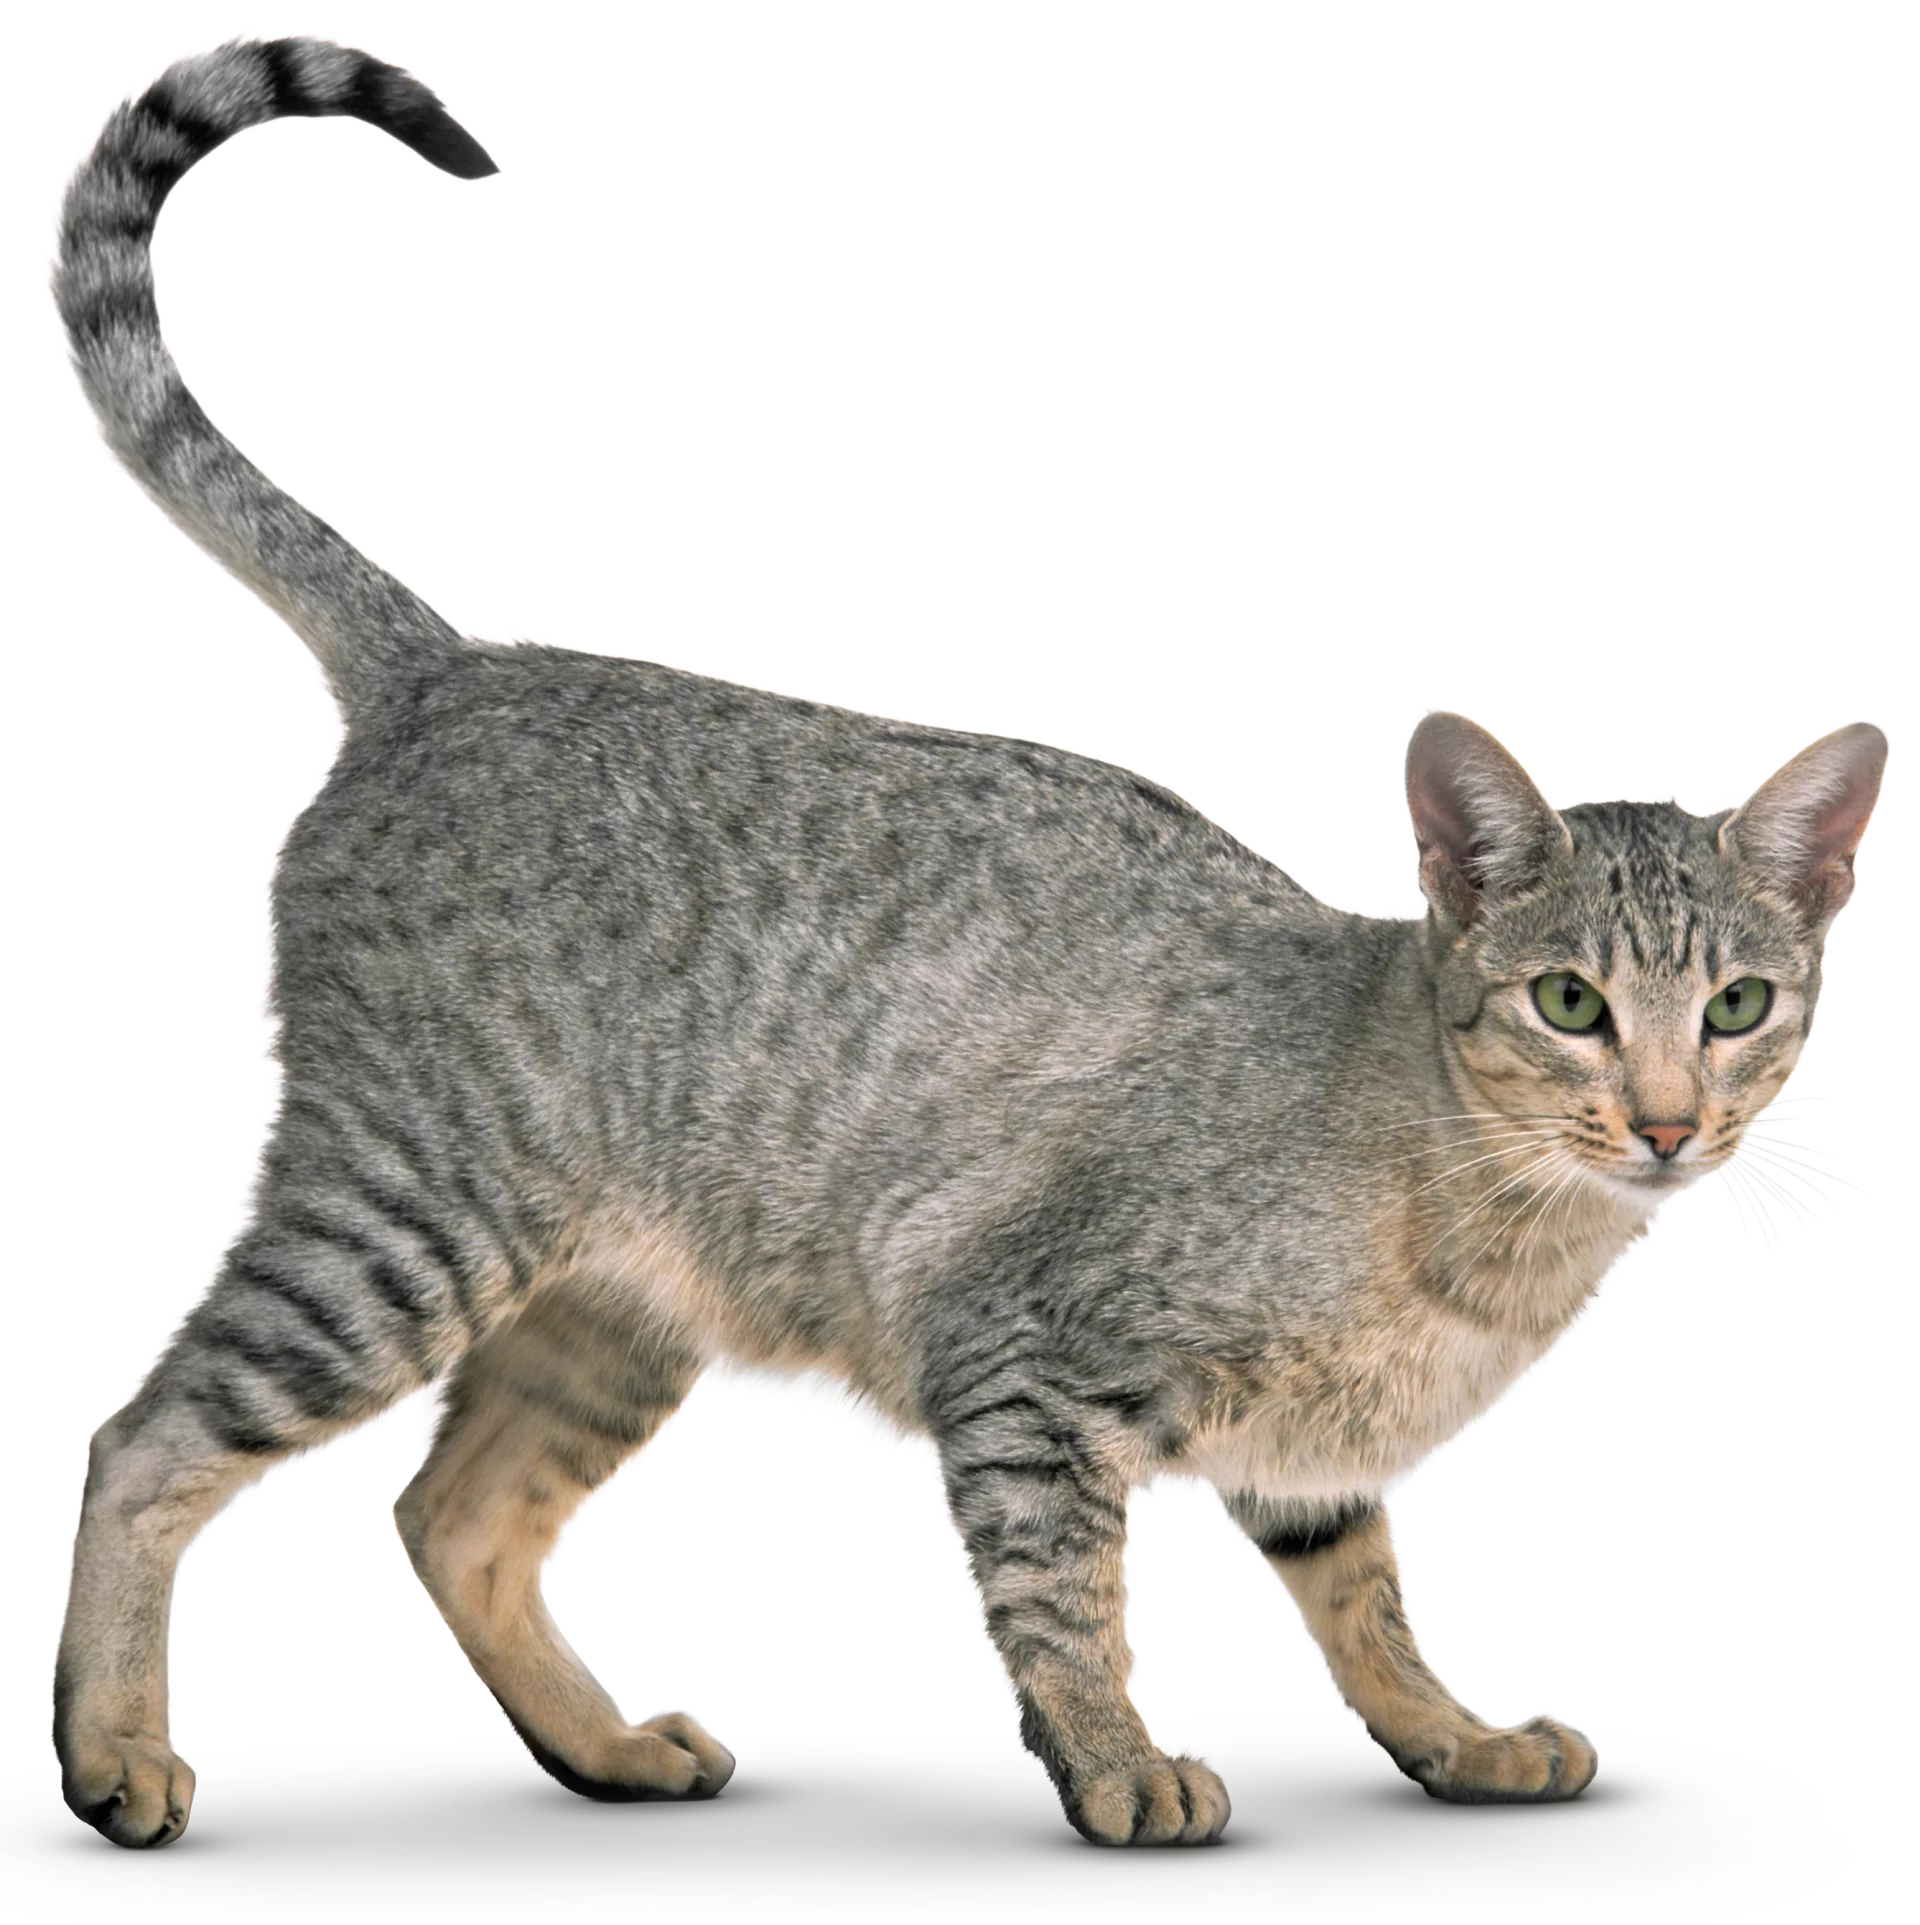

In [2]:
from IPython.display import Image, display
display(Image('../images/cat_image.webp', width=300))

### Using `meta-llama/llama-4-scout-17b-16e-instruct` with OpenAI Responses API (Groq Router)

In [6]:
from openai import OpenAI
import base64       # to encode the image into Base64
from IPython.display import Markdown, display

# -------------------------
# Load your image as base64
# -------------------------
with open("../images/cat_image.webp", "rb") as f:
    base64_image = base64.b64encode(f.read()).decode("utf-8")


# Initialize OpenAI client pointed at Groq
client = OpenAI(base_url="https://api.groq.com/openai/v1", api_key=groq_api_key)

response = client.responses.create(
                                    model="meta-llama/llama-4-scout-17b-16e-instruct",  # Vision-capable model
                                    input=[
                                            {"role": "system", "content": [{"type": "input_text", "text": "You are a helpful assistant."}]},
                                            {"role": "user","content": [
                                                                        {"type": "input_text", "text": "Tell me what you see in this image:"},                 # Text prompt
                                                                        {"type": "input_image", "image_url": f"data:image/webp;base64,{base64_image}"}
                                                                      ]
                                            }
                                        ],
                                    max_output_tokens=512,
                                    temperature=0.7
                                )
print(response.output_text)

The image shows a cat with a slender body, long tail, and green eyes. The cat is facing the camera but is angled slightly to the right, with its head turned toward the viewer. Its fur is primarily gray with black stripes on its legs, tail, and back.

**Key Features:**

* **Body:** Slender
* **Tail:** Long
* **Eyes:** Green
* **Fur Color:** Primarily gray with black stripes on legs, tail, and back

The background of the image is white, suggesting that it may be a stock photo or a product image. Overall, the image presents a clear and detailed view of the cat's physical characteristics.


### Using `claude-3-5-haiku`

In [37]:
import base64       # for encoding the image into Base64
import anthropic    # for calling Anthropic's Claude models

# -------------------------
# Load your image as base64
# -------------------------
with open("../images/cat_image.webp", "rb") as f:
    base64_image = base64.b64encode(f.read()).decode("utf-8")

client = anthropic.Anthropic(api_key=anthropic_api_key)
response = client.messages.create(
                                    model="claude-3-5-haiku-20241022",   # or "claude-3-5-sonnet-20240620" or "claude-3-5-opus-20240620"
                                    max_tokens=500,
                                    messages=[{"role": "user","content": [{"type": "text", "text": "Yor are a helpful assistant. Tell me what you see in this image"}, 
                                                                          {"type": "image","source": {"type": "base64", "media_type": "image/webp","data": base64_image,
                                                }}]}]
                                )

print(response.content[0].text)
# media_type can be "image/png" , "image/gif" or "image/webp" if needed

The image shows a gray tabby cat standing in a full-body profile view against a white background. The cat has distinctive tiger-like stripes in shades of gray and a lighter underbelly. Its tail is held up and curved, and it has bright green eyes. The cat appears to be a medium-sized breed with a lean, muscular build. Its ears are perked up and alert, and it has a calm, somewhat neutral expression. The photograph is high-quality and clearly shows the cat's fur texture and detailed features.


### Using `vit-base-patch16-224`
- For Vision Transformer (ViT) image-classification models, you don’t strictly need a GPU, but using one (e.g., Google Colab GPU runtime) speeds up inference and batching significantly.
- A standard ViT-based image classification model on Hugging Face is available at: https://huggingface.co/google/vit-base-patch16-224
- It’s a “base-sized” version of Vision Transformer (ViT), pre-trained on ImageNet-21k (≈ 14 million images, ~21,843 classes) and then fine-tuned on ImageNet-1k (1 million images, 1,000 classes) at 224×224 resolution. 
- The model has around 86.6 million parameters and supports standard 224×224 RGB input (with common preprocessing: resizing + normalization). 
- The vit-base-patch16-224 model is built around:
    - ViT-Base architecture → splits an image into 16×16 patches, embeds them, adds positional encodings, and processes them with a Transformer encoder.
- The model processes input images by splitting them into 16×16 pixel patches, embedding each patch, adding positional embeddings, and feeding the resulting sequence through a standard Transformer-encoder, with a special [CLS] token representing the full image.
- The model has around 86.6 million parameters and supports standard 224×224 RGB input (with common preprocessing: resizing + normalization). 
- When you load this model for the first time, the following files are downloaded into your Hugging Face cache (~/.cache/huggingface/):
    - pytorch_model.bin (≈ 330 MB containing ~86M parameters)
    - config.json, preprocessor_config.json → a few KB
- Total size ≈ 330–350 MB, making it lighter than larger ViT models and suitable for fast CPU/GPU inference.

In [45]:
import base64
from transformers import pipeline

# -------------------------
# Load your image as base64
# -------------------------
with open("../images/cat_image.webp", "rb") as f:
    base64_image = base64.b64encode(f.read()).decode("utf-8")


# Load the image-to-text pipeline from the transformers library
pipe = pipeline("image-classification",  model = "google/vit-base-patch16-224",  device = -1)

response = pipe(base64_image)

# It returns a list of dictionaries
response

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use cpu


[{'label': 'Egyptian cat', 'score': 0.959642231464386},
 {'label': 'tabby, tabby cat', 'score': 0.025431443005800247},
 {'label': 'tiger cat', 'score': 0.012005770578980446},
 {'label': 'lynx, catamount', 'score': 0.0008211695239879191},
 {'label': 'Siamese cat, Siamese', 'score': 0.00022607913706451654}]

# 3. <span style='background :lightgreen' >Text → Image (Image Generation)</span>
Text-to-image generation is the process of transforming written descriptions into visual artworks using AI. By interpreting natural language prompts, these models can create anything from photorealistic scenes to imaginative illustrations, allowing users to bring ideas to life in diverse artistic styles.
- **Closed Source:**
    - **DALL-E 3:** DALL·E 3 — A high-fidelity text-to-image model by OpenAI that captures much more nuance and detail from prompts than its predecessors. (https://openai.com/dall-e-3/)
    - **GPT-4o:** OpenAI’s multimodal “omni” model which can take text (and other modalities) and generate or edit images conversationally with detailed control. (https://openai.com/index/introducing-4o-image-generation/)
    - **Midjourney:** Independent research lab’s text-to-image service known for highly artistic, stylistic, and richly detailed image generations from natural-language prompts. (https://www.midjourney.com/)
- **Open Source:**
    - **FLUX:** A family of models by Black Forest Labs; open-weight versions (e.g. FLUX.1 Dev / Schnell) generate images from text with over 12B parameters, strong prompt fidelity, and competitive output quality. (https://bfl.ai/)
    - **Stable Diffusion XL:** An advanced diffusion-based open model by Stability AI that produces more realistic faces, better composition, legible text and high detail even from shorter/simpler prompts. (https://stablediffusionxl.com/)
- **Example Prompts:**
    - "A futuristic city with flying cars at sunset."
    - "A cartoon cat teaching math on a blackboard."
    - Prompt: "An ancient library with floating books and magical lighting."


>- Currently, neither GPT-4 nor Claude can generate, edit, or transform images. However, they can:
    >- Analyze and describe image content
    >- Extract text from images (OCR)
    >- Answer questions about what's in an image
    >- Identify objects, people, scenes
    >- Read charts, diagrams, and documents
    >- Provide detailed analysis of visual elements

### Using `dall-e-3`
- OpenAI’s DALL·E models (DALL·E 2 and DALL·E 3) enable AI-powered image creation and manipulation through the OpenAI Images API. The key endpoints are:
    - **`client.images.generate():`** method sends a text prompt to OpenAI's DALL-E model via API and returns AI-generated images based on that description.
    - **`client.images.create_variation():`** Creates variations of an existing image.
    - **`client.images.edit():`** Takes an input image (and optional mask) plus a prompt to edit or modify the image.

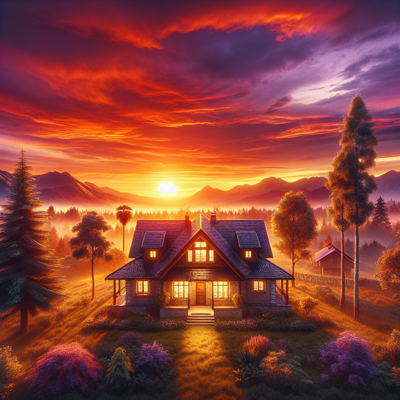

In [63]:
from openai import OpenAI      # OpenAI Python client
import base64                  # for encoding/decoding images in base64
from PIL import Image          # to open and work with images
from io import BytesIO         # to handle binary image data in memory
from IPython.display import display  # to display the image in Jupyter Notebook

client = OpenAI(api_key=openai_api_key)
# The `client.images.generate()` method sends a text prompt to OpenAI's DALL-E model via API and returns AI-generated images based on that description.
image_response = client.images.generate(
                            model="dall-e-3",
                            prompt="Create  an image of a house, with sun set in the back ground having trees and mountains",
                            style='vivid',      # can be 'standard' or 'hd'
                            size="1024x1024",   # specifies the dimensions of the image. For dall-e-3 it can have values: "1024x1024", "1024x1792" (portrait), "1792x1024" (landscape). For dall-e-2 it can have values: "256x256", "512x512", "1024x1024"
                            quality='standard', # 
                            n=1,                #
                            response_format="b64_json",  # specifies the format of the image to be returned. It can be 'b64_json', which will return the image as base64-encoded JSON data. It can also be 'url', in which case you need to download image  (the url inside `image_response.data[0].url` and it expires in 1 hour)
                        )

image_base64 = image_response.data[0].b64_json # Extracts the base64-encoded image string from the API response
image_data = base64.b64decode(image_base64)    # decodes the text representation of the image from base64 back into raw binary image data. 
image = Image.open(BytesIO(image_data))        # `BytesIO(image_data)` creates an in-memory file-like object from the binary data, and `Image.open()` uses PIL/Pillow to open the image from the memory buffer
image.thumbnail((400, 400))                    # Resize maintaining aspect ratio
display(image)

### Using `stabilityai/sd-turbo`
- The https://huggingface.co/stabilityai/sd-turbo  model is a fast, optimized Stable Diffusion checkpoint hosted on Hugging Face. The following files are downloaded into your Hugging Face cache (~/.cache/huggingface/ by default):
    - `pytorch_model.bin` (UNet weights) → ~ 1.3 GB
    - `vae/diffusion_pytorch_model.bin` (VAE weights) → ~ 335 MB
    - `text_encoder/pytorch_model.bin` (CLIP text encoder) → ~ 500 MB
    - tokenizer, scheduler, config.json, model_index.json, etc. → a few MB
- Total size ≈ 2.1 – 2.2 GB. This is much lighter than standard Stable Diffusion checkpoints (like v1-5) and optimized for faster CPU/GPU inference. Once downloaded, the files are cached locally and won’t be re-downloaded unless the cache is cleared.

In [1]:
from diffusers import AutoPipelineForText2Image
import torch             #  Import PyTorch deep learning framework for tensor operations and GPU acceleration
from PIL import Image

img_generator = AutoPipelineForText2Image.from_pretrained(
                                                        "stabilityai/sd-turbo",   # ~1.3GB, optimized for fast CPU/GPU inference
                                                        dtype=torch.float32 # safer for CPU (no float16 issues)
                                                        ).to("cpu")

/Users/arif/Documents/genai-course/.venv/lib/python3.12/site-packages/diffusers/models/transformers/transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
/Users/arif/Documents/genai-course/.venv/lib/python3.12/site-packages/diffusers/models/transformers/transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
Keyword arguments {'dtype': torch.float32} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/10 [00:00<?, ?it/s]

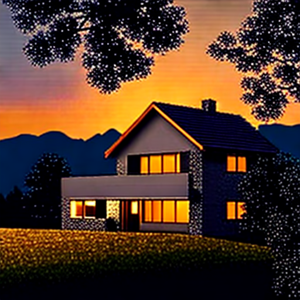

In [2]:
from IPython.display import display  # to display the image in Jupyter Notebook

prompt = "Create  an image of a house, with sun set in the back ground having trees and mountains"

# The pipeline returns a result object with a list of generated images. Since we only asked for one image, we grab the first (.images[0]).
image = img_generator(
        prompt=prompt, 
        num_inference_steps=10,  # controls how many denoising steps the diffusion model runs. More steps = better quality & more detail (but slower). On CPU, 20 is a reasonable tradeoff (default is usually 50).
        guidance_scale=7.5,      # controls how strongly the model follows your prompt. Higher values (e.g., 10–15) → stick closer to your words, but may reduce creativity. Lower values (e.g., 3–5) → more freedom, but less prompt adherence.
        height=512,              # reduce resolution for speed (default is 512x512)
        width=512
        )

# Display the image 
image_resized = image.images[0].resize((300, 300))
display(image_resized)

  0%|          | 0/10 [00:00<?, ?it/s]

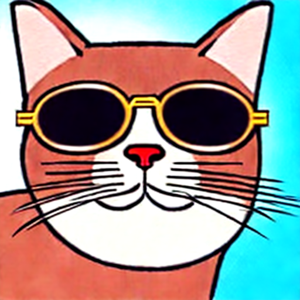

In [77]:
from IPython.display import display  # to display the image in Jupyter Notebook

prompt = "A cute cartoon cat wearing sunglasses"

# The pipeline returns a result object with a list of generated images. Since we only asked for one image, we grab the first (.images[0]).
image = img_generator(
        prompt=prompt, 
        num_inference_steps=10,  # controls how many denoising steps the diffusion model runs. More steps = better quality & more detail (but slower). On CPU, 20 is a reasonable tradeoff (default is usually 50).
        guidance_scale=7.5,     # controls how strongly the model follows your prompt. Higher values (e.g., 10–15) → stick closer to your words, but may reduce creativity. Lower values (e.g., 3–5) → more freedom, but less prompt adherence.
        height=512,              # reduce resolution for speed (default is 512x512)
        width=512
        )

# Display the image 
image_resized = image.images[0].resize((300, 300))
display(image_resized)

  0%|          | 0/10 [00:00<?, ?it/s]

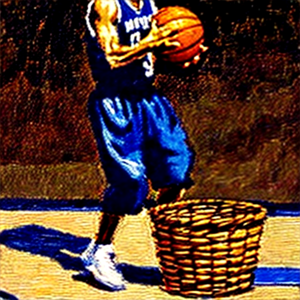

In [78]:
from IPython.display import display  # to display the image in Jupyter Notebook

prompt = "An oil painting of a basket player making a basket"

# The pipeline returns a result object with a list of generated images. Since we only asked for one image, we grab the first (.images[0]).
image = img_generator(
        prompt=prompt, 
        num_inference_steps=10,  # controls how many denoising steps the diffusion model runs. More steps = better quality & more detail (but slower). On CPU, 20 is a reasonable tradeoff (default is usually 50).
        guidance_scale=7.5,     # controls how strongly the model follows your prompt. Higher values (e.g., 10–15) → stick closer to your words, but may reduce creativity. Lower values (e.g., 3–5) → more freedom, but less prompt adherence.
        height=512,              # reduce resolution for speed (default is 512x512)
        width=512
        )

# Display the image 
image_resized = image.images[0].resize((300, 300))
display(image_resized)

  0%|          | 0/10 [00:00<?, ?it/s]

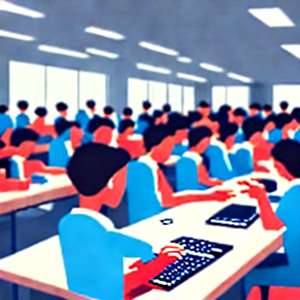

In [79]:
from IPython.display import display  # to display the image in Jupyter Notebook

prompt = "A futuristic class full of students learning AI coding"

# The pipeline returns a result object with a list of generated images. Since we only asked for one image, we grab the first (.images[0]).
image = img_generator(
        prompt=prompt, 
        num_inference_steps=10,  # controls how many denoising steps the diffusion model runs. More steps = better quality & more detail (but slower). On CPU, 20 is a reasonable tradeoff (default is usually 50).
        guidance_scale=7.5,     # controls how strongly the model follows your prompt. Higher values (e.g., 10–15) → stick closer to your words, but may reduce creativity. Lower values (e.g., 3–5) → more freedom, but less prompt adherence.
        height=512,              # reduce resolution for speed (default is 512x512)
        width=512
        )

# Display the image 
image_resized = image.images[0].resize((300, 300))
display(image_resized)

# 4. <span style='background :lightgreen' >Image → Image (Image Segmentation)</span>

### Using `mattmdjaga/segformer_b2_clothes`
- It's a specialized semantic segmentation model that identifies 18 different clothing and body part categories, with 27.4M parameters. The model segments images into regions like:
    - Background, Hat, Hair, Sunglasses
    - Upper-clothes, Skirt, Pants, Dress
    - Belt, Left-shoe, Right-shoe
    - Face, Left-leg, Right-leg, Left-arm, Right-arm
    - Bag, Scarf

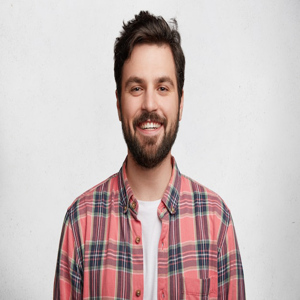

In [80]:
from PIL import Image        # For opening and manipulating images
import requests              # To fetch the image from a URL
from IPython.display import display  # To display the image in Jupyter/Colab

url = "https://img.freepik.com/free-photo/young-bearded-man-with-striped-shirt_273609-5677.jpg"
image = Image.open(requests.get(url, stream=True).raw)
# Resize to 300x300 (keep aspect ratio if needed)
image_resized = image.resize((300, 300))
display(image_resized)

In [51]:
from transformers import pipeline
pipe = pipeline("image-segmentation", model="mattmdjaga/segformer_b2_clothes")
outputs = pipe(image)
outputs

Device set to use mps:0


[{'score': None,
  'label': 'Background',
  'mask': <PIL.Image.Image image mode=L size=626x417>},
 {'score': None,
  'label': 'Hair',
  'mask': <PIL.Image.Image image mode=L size=626x417>},
 {'score': None,
  'label': 'Upper-clothes',
  'mask': <PIL.Image.Image image mode=L size=626x417>},
 {'score': None,
  'label': 'Face',
  'mask': <PIL.Image.Image image mode=L size=626x417>}]

- The above output gives a list of 4 grayscale masks, one for each detected class:
>  - Background
>  - Hair
>  - Upper-clothes
>  - Face
- Each mask is the same size as the input image (626x417 in this example).
- You can display each mask using mask.show() or convert it to a numpy array for further processing.

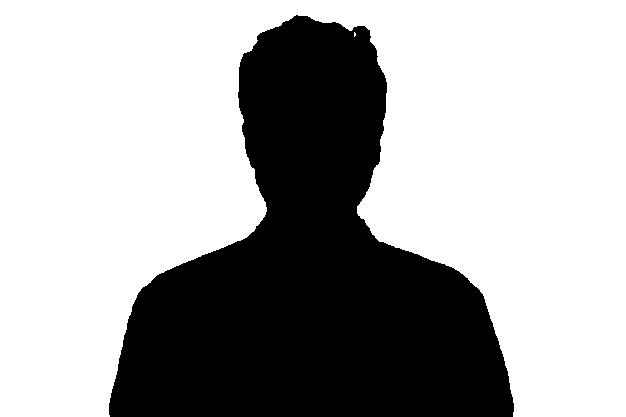

In [53]:
# Background
outputs[0]['mask']

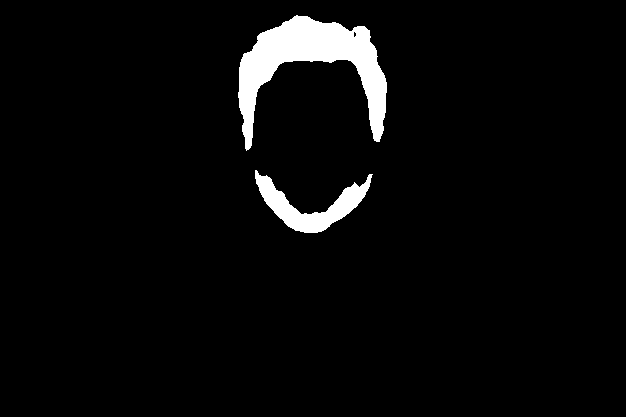

In [83]:
# Hair
outputs[1]['mask']

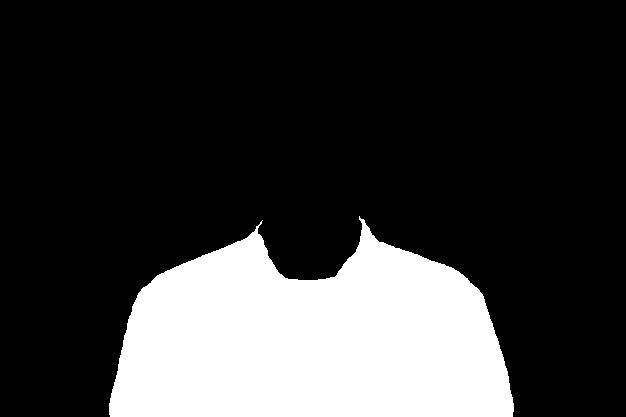

In [84]:
# Upper clothes
outputs[2]['mask']

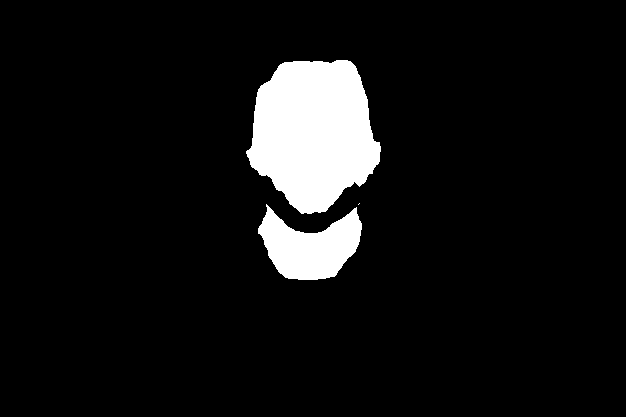

In [85]:
# Face
outputs[3]['mask']